###  RobustScaler-Normalization 

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
data = r"robust_scaler_practice_50_rows.csv"
df = pd.read_csv(data)
df.columns = ['Experience','Age','Annual_Income','Salary']

In [4]:
df.head()

,Experience,Age,Annual_Income,Salary
0,22,0,28000,30000
1,23,1,30000,32000
2,24,1,32000,34000
3,25,2,34000,36000
4,26,3,36000,38000


In [14]:
df.describe()

,Experience,Age,Annual_Income,Salary
count,50.00000,50.000000,5.000000e+01,50.000000
mean,46.50000,23.540000,1.421600e+05,79000.000000
std,14.57738,14.511375,2.606738e+05,29154.759474
min,22.00000,0.000000,2.800000e+04,30000.000000
25%,34.25000,11.250000,5.250000e+04,54500.000000
50%,46.50000,23.500000,7.700000e+04,79000.000000
75%,58.75000,35.750000,1.015000e+05,103500.000000
max,71.00000,48.000000,1.500000e+06,128000.000000


In [11]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(df.drop("Salary",axis=1),df["Salary"],test_size=.3,random_state=42)

X_train.shape,X_test.shape

((35, 3), (15, 3))

In [24]:
X_train.describe()

,Experience,Age,Annual_Income
count,35.000000,35.000000,3.500000e+01
mean,46.771429,23.828571,1.456000e+05
std,14.804780,14.709912,2.720090e+05
min,22.000000,0.000000,2.800000e+04
25%,34.500000,11.500000,5.300000e+04
50%,46.000000,23.000000,7.600000e+04
75%,59.000000,36.000000,1.020000e+05
max,71.000000,48.000000,1.500000e+06


In [12]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)



In [13]:
X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=X_test.columns,
    index=X_test.index
)


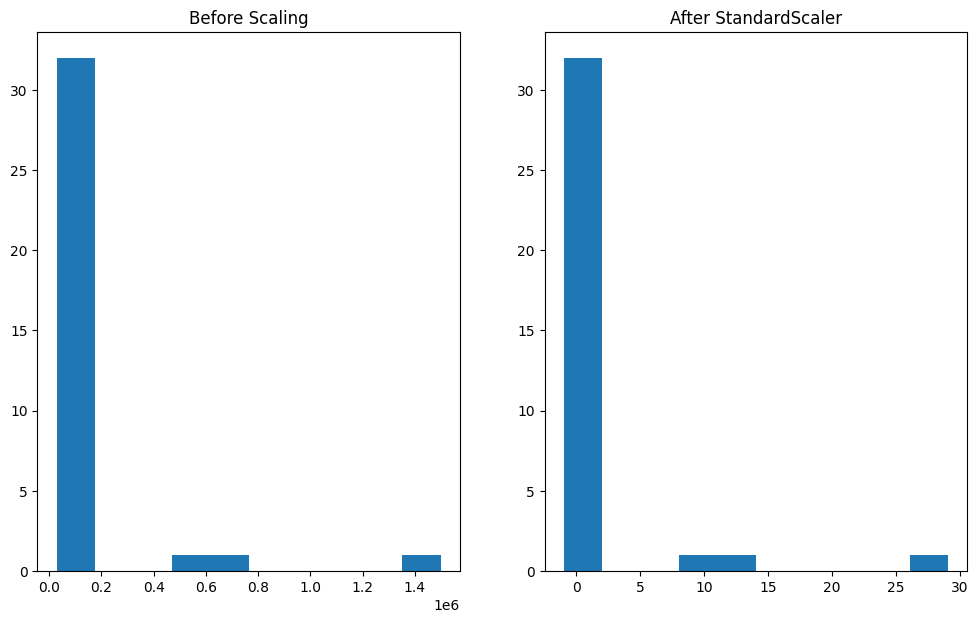

In [14]:

fig, (ax1, ax2) = plt.subplots(figsize=(12, 7), ncols=2)

ax1.set_title("Before Scaling")
ax1.hist(X_train["Annual_Income"])

ax2.set_title("After StandardScaler")
ax2.hist(X_train_scaled["Annual_Income"])

plt.show()

<Axes: title={'center': 'After Scaling'}, xlabel='Annual_Income', ylabel='Density'>

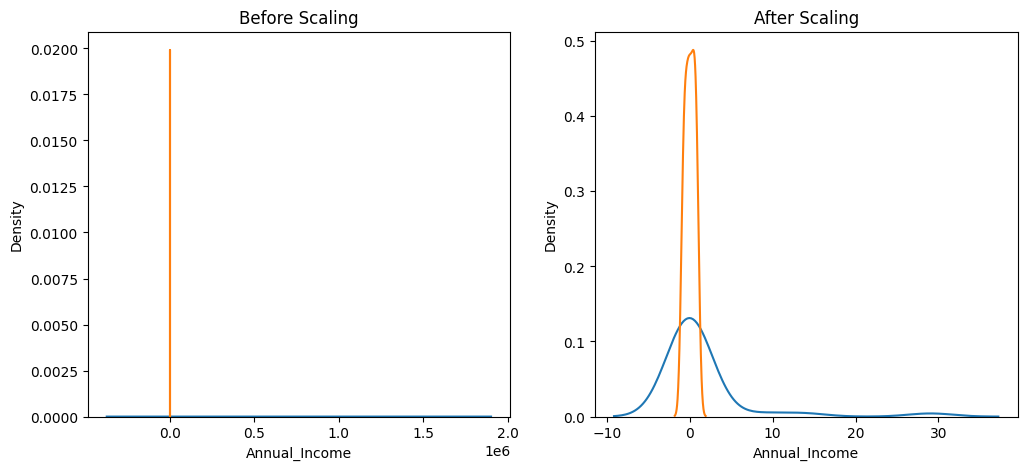

In [19]:

fig, (ax1, ax2) = plt.subplots(figsize=(12, 5), ncols=2)

ax1.set_title("Before Scaling")

sns.kdeplot(X_train["Annual_Income"],ax=ax1)
sns.kdeplot(X_train["Age"],ax=ax1)

ax2.set_title("After Scaling")
sns.kdeplot(X_train_scaled["Annual_Income"],ax=ax2)
sns.kdeplot(X_train_scaled["Age"],ax=ax2)

